# Solar Sub-Analysis — ERCOT Houston Hub

**Goal**: Evaluate whether adding solar generation features improves RTM volatility prediction, focusing on summer months (Jun–Sep) where solar penetration is highest.

**Motivation**: NP4-745-CD (solar actual + STPPF forecast) starts 2022-06 — too short for the full 2017–2024 training window used in `modeling.ipynb`. This notebook uses a constrained train window (2022-06 → 2024-12) to enable a fair apples-to-apples comparison.

**Design**:
- **Train**: 2022-06-01 → 2024-12-31 (constrained by solar data availability)
- **Test**: 2025-01-01 → 2025-12-31 (same test set as main model)
- **Baseline**: XGBoost v3 (30 feat incl. GARCH) — same architecture, narrower train window
- **Treatment**: XGBoost v3 + solar features (32 feat)
- **Primary metric**: R² overall + R² Jun–Sep (summer)

**Run order**: run `data_cleaning.ipynb` first (provides processed parquets). `modeling.ipynb` does NOT need to be run first — GARCH is recomputed here.

**Solar features added**:
- `solar_actual_lag48`: actual solar gen from 48h ago (MW) — leakage-safe, parallels `load_houston_lag48`
- `solar_forecast_mw`: STPPF day-ahead forecast for delivery hour, posted D-1 before midnight — available at prediction cutoff
- `solar_error_lag48`: forecast error (actual − forecast) from 48h ago — encodes recent solar forecast quality

## 1. Setup

In [1]:
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
from arch import arch_model
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
import os; os.makedirs('figures/solar', exist_ok=True)

TRAIN_START = '2022-06-01'
TRAIN_END   = '2024-12-31'
TEST_START  = '2025-01-01'
TEST_END    = '2025-12-31'
SOLAR_ARCHIVE = 'data/archive/ercot/NP4-745-CD/NP4-745-CD'

# XGBoost v3 hyperparameters (same as modeling.ipynb §7.3.1)
XGB_PARAMS = dict(
    n_estimators=600, max_depth=5, learning_rate=0.05,
    min_child_weight=3, gamma=0.0, reg_alpha=0.1,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbosity=0
)
print('Setup complete.')

Setup complete.


## 2. Load Base Features

In [2]:

train_all = pd.read_parquet('data/processed/ercot/train_features.parquet').reset_index()
test_all  = pd.read_parquet('data/processed/ercot/test_features.parquet').reset_index()

# Subset train to solar window
train = train_all[(train_all['ts_cst'] >= TRAIN_START) & (train_all['ts_cst'] <= TRAIN_END)].copy().reset_index(drop=True)
test  = test_all.copy().reset_index(drop=True)

# ── Column-specific imputation (matches modeling.ipynb strategy) ──────────────
# ffill for time-series lag features (preserves temporal structure)
for _col in ['rtm_std_lag24', 'load_houston_lag48']:
    if _col in train.columns:
        train[_col] = train[_col].ffill()
        test[_col]  = test[_col].ffill()

# Median imputation for price/market features (fit on train, apply to both)
_price_cols = ['dam_price_houston', 'system_lambda',
               'mcpc_regup', 'mcpc_rrs', 'mcpc_nspin', 'mcpc_regdn']
for _col in _price_cols:
    if _col in train.columns:
        _med = train[_col].median()
        train[_col] = train[_col].fillna(_med)
        test[_col]  = test[_col].fillna(_med)

# total_resource_mw: keep fillna(0) — nulls are pre-2022, solar train starts 2022-06
if 'total_resource_mw' in train.columns:
    train['total_resource_mw'] = train['total_resource_mw'].fillna(0)
    test['total_resource_mw']  = test['total_resource_mw'].fillna(0)

print(f'Train: {len(train):,} rows  ({train["ts_cst"].min().date()} → {train["ts_cst"].max().date()})')
print(f'Test:  {len(test):,} rows  ({test["ts_cst"].min().date()} → {test["ts_cst"].max().date()})')

# Base features — 22 features, matching FEAT_V2_XGB base (updated 2026-03-22)
# rtm_mean/std renamed to lag24 (D-1 lag, safe at 00:05 CST cutoff)
# system_lambda kept for XGBoost (handles collinearity; excluded only for linear models)
FEATS_BASE = [
    'dam_price_houston', 'system_lambda', 'load_houston_lag48',
    'rtm_mean_lag24', 'rtm_std_lag24', 'total_resource_mw',
    'wgrpp_lz_south_houston', 'wind_error_houston',
    'fc_coast', 'fc_system_total', 'wf_stwpf_lz_south_houston',
    'temp_f_houston_avg', 'humidity_pct_houston_avg',
    'wind_gust_mph_houston_avg', 'precip_in_houston_avg',
    'mcpc_regup', 'mcpc_rrs', 'mcpc_nspin', 'mcpc_regdn',
    'hour', 'month', 'dow',
]

# Verify columns exist in parquet
missing = [c for c in FEATS_BASE if c not in train.columns]
if missing:
    print(f'⚠ Missing base columns: {missing}')
else:
    print(f'Base features ({len(FEATS_BASE)}): all present ✓')

Train: 22,657 rows  (2022-06-01 → 2024-12-31)
Test:  8,760 rows  (2025-01-01 → 2025-12-31)
Base features (22): all present ✓


## 3. Add Engineered Features (v2 additions)

Mirrors the feature engineering in `modeling.ipynb` §7 — computed fresh here.

In [3]:

rtm_hourly = pd.read_parquet('data/processed/ercot/np6_905_rtm_hourly_houston.parquet')[
    ['ts_cst', 'rtm_price_mean', 'rtm_price_std']
].copy()

# Use already-loaded full feature history (from solar-load-base) for load_lag7d lookup
_all_feats_hist  = train_all.copy()
_test_feats_hist = test_all.copy()
_load_hist = pd.concat([_all_feats_hist, _test_feats_hist]).set_index('ts_cst')['load_houston_lag48']

def add_v2_features(df, rtm_h, load_hist):
    df = df.copy()
    # fc_net_load = coast load forecast - Houston wind forecast
    df['fc_net_load'] = df['fc_coast'] - df['wf_stwpf_lz_south_houston']
    # dam_rtm_spread uses rtm_mean_lag24 (D-1 lag, updated 2026-03-22)
    df['dam_rtm_spread'] = df['dam_price_houston'] - df['rtm_mean_lag24']
    df['abs_dam_rtm_spread'] = df['dam_rtm_spread'].abs()
    # Calendar
    df['week'] = df['ts_cst'].dt.isocalendar().week.astype(int)
    # 7-day lags via lookup into RTM hourly parquet
    rtm_idx = rtm_h.set_index('ts_cst')
    ts_lag7d = df['ts_cst'] - pd.Timedelta(hours=7*24)
    df['rtm_price_std_lag7d']  = ts_lag7d.map(rtm_idx['rtm_price_std'])
    df['rtm_price_mean_lag7d'] = ts_lag7d.map(rtm_idx['rtm_price_mean'])
    # load_lag7d — load_houston_lag48 from 7 days prior (matches main model)
    df['load_lag7d'] = ts_lag7d.map(load_hist)
    # Outage fraction — matches main model formula
    df['outage_fraction'] = df['total_resource_mw'] / (df['fc_system_total'] + 1)
    return df

train = add_v2_features(train, rtm_hourly, _load_hist)
test  = add_v2_features(test,  rtm_hourly, _load_hist)

FEATS_V2_EXTRA = ['fc_net_load', 'dam_rtm_spread', 'abs_dam_rtm_spread', 'week',
                  'load_lag7d', 'rtm_price_std_lag7d', 'rtm_price_mean_lag7d', 'outage_fraction']
FEATS_V2 = FEATS_BASE + FEATS_V2_EXTRA
print(f'V2 features: {len(FEATS_V2)}  (matches FEAT_V2_XGB=30 in main model)')

# Check for unexpected NaN rates
for col in FEATS_V2_EXTRA:
    nan_pct = train[col].isna().mean() * 100
    if nan_pct > 1:
        print(f'  ⚠ {col}: {nan_pct:.1f}% NaN in train')

V2 features: 30  (matches FEAT_V2_XGB=30 in main model)
  ⚠ dam_rtm_spread: 2.8% NaN in train
  ⚠ abs_dam_rtm_spread: 2.8% NaN in train
  ⚠ load_lag7d: 2.8% NaN in train


## 4. GARCH Conditional Volatility Feature

Recomputed from scratch on the 2022–2024 training window using the same GARCH(1,1)-t specification as `modeling.ipynb` §7.3. Leakage-safe: test σ_t is produced via manual GARCH recursion using only training-window parameters and D-2 residuals.

In [4]:

def compute_garch_vol(train_df, oos_df, target_col='log_rtm_std'):
    """
    Fit GARCH(1,1)-t on train residuals; return conditional vol with D-1 lag.

    Leakage design (matches main model, updated 2026-03-22):
      garch_cond_vol[t] = sqrt(ω + α·ε²[t-24] + β·σ²[t-24])

    Full forward recursion runs through OOS (using actual residuals to propagate
    σ² correctly), then the result is shifted 24h so each prediction only sees
    GARCH state from 24 hours earlier — safe at 00:05 CST cutoff.
    """
    import statsmodels.api as sm

    full = pd.concat([
        train_df[['ts_cst', target_col, 'hour', 'month', 'dow']],
        oos_df[['ts_cst', target_col, 'hour', 'month', 'dow']]
    ], ignore_index=True)
    full = full.dropna(subset=[target_col]).sort_values('ts_cst').reset_index(drop=True)

    # Seasonal OLS to detrend
    X = pd.get_dummies(full[['hour', 'month', 'dow']].astype(str), drop_first=True).astype(float)
    X = sm.add_constant(X)
    ols = sm.OLS(full[target_col], X).fit()
    resid = ols.resid.values

    n_train = len(train_df.dropna(subset=[target_col]))
    train_resid = resid[:n_train]
    garch = arch_model(train_resid * 100, vol='Garch', p=1, q=1, dist='t')
    res = garch.fit(disp='off')
    omega = float(res.params['omega'])
    alpha = float(res.params['alpha[1]'])
    beta  = float(res.params['beta[1]'])

    # Full forward GARCH recursion (propagates σ² through OOS using actual residuals)
    all_resid = resid * 100
    sigma2_full = np.empty(len(full))
    sigma2_full[:n_train] = res.conditional_volatility ** 2
    last_s2   = float(sigma2_full[n_train - 1])
    last_eps2 = float(all_resid[n_train - 1] ** 2)
    for t in range(len(full) - n_train):
        s2 = omega + alpha * last_eps2 + beta * last_s2
        sigma2_full[n_train + t] = s2
        last_s2   = s2
        last_eps2 = float(all_resid[n_train + t] ** 2)

    # D-1 lag: feature at t uses GARCH state from t-24
    lag = 24
    eps2_all = all_resid ** 2
    sigma2_lagged = np.full(len(full), np.nan)
    sigma2_lagged[lag:] = omega + alpha * eps2_all[:-lag] + beta * sigma2_full[:-lag]
    cond_vol_all = np.sqrt(np.maximum(sigma2_lagged, 0)) / 100

    ts_to_vol = dict(zip(full['ts_cst'].values, cond_vol_all))
    return ts_to_vol

print('Computing GARCH(1,1)-t conditional vol (D-1 lag, 2022-2024 train)...')
ts_to_vol = compute_garch_vol(train, test)

train['garch_cond_vol'] = train['ts_cst'].map(ts_to_vol)
test['garch_cond_vol']  = test['ts_cst'].map(ts_to_vol)

# First 24 rows will be NaN (D-1 lag); fill with train mean for XGBoost
_garch_train_mean = train['garch_cond_vol'].mean()
train['garch_cond_vol'] = train['garch_cond_vol'].fillna(_garch_train_mean)
test['garch_cond_vol']  = test['garch_cond_vol'].fillna(_garch_train_mean)

print(f"GARCH vol — train: mean={train['garch_cond_vol'].mean():.3f}  "
      f"test: mean={test['garch_cond_vol'].mean():.3f}  "
      f"max={train['garch_cond_vol'].max():.3f}")

FEATS_V3 = FEATS_V2 + ['garch_cond_vol']
print(f'V3 features: {len(FEATS_V3)}  (matches FEAT_V3=31 in main model)')


Computing GARCH(1,1)-t conditional vol (D-1 lag, 2022-2024 train)...


GARCH vol — train: mean=0.883  test: mean=0.769  max=5.810
V3 features: 31  (matches FEAT_V3=31 in main model)


## 5. Solar Feature Engineering

**Source**: NP4-745-CD — Solar Actual Generation + Short-Term PV Power Forecast (STPPF), posted hourly with 7-day rolling window.

**Column guide**:
- `GEN_SYSTEM_WIDE`: actual solar generation (MW) — updated after delivery; requires D-2 lag
- `STPPF_SYSTEM_WIDE`: short-term photovoltaic power forecast (MW) — posted D-1 morning; available at midnight D
- `PVGRPP_SYSTEM_WIDE`: PV generation resource plan (MW) — generator-submitted plan; available day-ahead

**Leakage-safe strategy**:
- `solar_actual_lag48`: `GEN_SYSTEM_WIDE` from 48h prior — parallels `load_houston_lag48`
- `solar_forecast_mw`: `STPPF_SYSTEM_WIDE` from posting with horizon 18–36h (D-1 morning, available at midnight)
- `solar_error_lag48`: actual − forecast from 48h ago — captures solar forecast quality regime

In [5]:
import glob

solar_files = sorted(glob.glob(f'{SOLAR_ARCHIVE}/**/*.csv', recursive=True))
solar_files = [f for f in solar_files if '.docid' not in f and '.sortcache' not in f]
print(f'Found {len(solar_files)} solar CSV files')

chunks = []
for f in tqdm(solar_files, desc="Loading solar CSVs"):
    try:
        df = pd.read_csv(f, low_memory=False)
        # Schema changed in 2025: GEN_SYSTEM_WIDE -> SYSTEM_WIDE_GEN
        if 'SYSTEM_WIDE_GEN' in df.columns and 'GEN_SYSTEM_WIDE' not in df.columns:
            df = df.rename(columns={'SYSTEM_WIDE_GEN': 'GEN_SYSTEM_WIDE'})
        keep = ['postDateTime', 'DELIVERY_DATE', 'HOUR_ENDING',
                'GEN_SYSTEM_WIDE', 'STPPF_SYSTEM_WIDE', 'PVGRPP_SYSTEM_WIDE']
        keep = [c for c in keep if c in df.columns]
        chunks.append(df[keep])
    except Exception as e:
        print(f'  skip {f}: {e}')

solar_raw = pd.concat(chunks, ignore_index=True)
print(f'Raw solar: {len(solar_raw):,} rows')

# Parse types
solar_raw['postDateTime'] = pd.to_datetime(solar_raw['postDateTime'], errors='coerce')
solar_raw['HOUR_ENDING'] = pd.to_numeric(solar_raw['HOUR_ENDING'], errors='coerce')
for c in ['GEN_SYSTEM_WIDE', 'STPPF_SYSTEM_WIDE', 'PVGRPP_SYSTEM_WIDE']:
    if c in solar_raw.columns:
        solar_raw[c] = pd.to_numeric(solar_raw[c], errors='coerce')

solar_raw = solar_raw.dropna(subset=['postDateTime', 'HOUR_ENDING'])

# Delivery timestamp (CST, no DST: fixed UTC-6)
_del_date = pd.to_datetime(solar_raw['DELIVERY_DATE'])
_he = solar_raw['HOUR_ENDING'].astype(int).clip(1, 24)
solar_raw['ts_cst'] = _del_date + pd.to_timedelta(_he - 1, unit='h')
solar_raw['horizon_h'] = (solar_raw['ts_cst'] - solar_raw['postDateTime']).dt.total_seconds() / 3600

print(f'Date range: {solar_raw["ts_cst"].min()} → {solar_raw["ts_cst"].max()}')
print(f'Horizon range: [{solar_raw["horizon_h"].min():.1f}, {solar_raw["horizon_h"].max():.1f}]')
print('Delivery hours by year:')
print(solar_raw.groupby(solar_raw['ts_cst'].dt.year)['ts_cst'].nunique())

Found 45 solar CSV files


Loading solar CSVs:   0%|          | 0/45 [00:00<?, ?it/s]

Raw solar: 6,909,206 rows


Date range: 2022-06-28 16:00:00 → 2026-03-01 22:00:00
Horizon range: [-57.2, 166.1]
Delivery hours by year:


ts_cst
2022    4472
2023    8759
2024    8783
2025    8759
2026    1439
Name: ts_cst, dtype: int64


In [6]:
# ── Solar actual: keep last posting per delivery slot (most recent actual) ─────
solar_actual = (
    solar_raw
    .sort_values('postDateTime')
    .drop_duplicates(subset='ts_cst', keep='last')
    [['ts_cst', 'GEN_SYSTEM_WIDE']]
    .rename(columns={'GEN_SYSTEM_WIDE': 'solar_actual_mw'})
    .set_index('ts_cst')
)

# ── Solar forecast: D-1 posting (horizon 18–36h, available at midnight D) ──────
solar_fc = (
    solar_raw[(solar_raw['horizon_h'] >= 18) & (solar_raw['horizon_h'] <= 36)]
    .sort_values('postDateTime')
    .drop_duplicates(subset='ts_cst', keep='last')
    [['ts_cst', 'STPPF_SYSTEM_WIDE', 'PVGRPP_SYSTEM_WIDE']]
    .rename(columns={'STPPF_SYSTEM_WIDE': 'solar_forecast_mw',
                     'PVGRPP_SYSTEM_WIDE': 'solar_plan_mw'})
    .set_index('ts_cst')
)

print(f'Solar actual: {len(solar_actual):,} delivery hours')
print(f'Solar forecast: {len(solar_fc):,} delivery hours with D-1 posting')

def merge_solar(df):
    df = df.copy()
    ts = df['ts_cst']
    ts_lag48 = ts - pd.Timedelta(hours=48)

    # Actual from 48h ago
    df['solar_actual_lag48'] = ts_lag48.map(solar_actual['solar_actual_mw'])

    # Day-ahead forecast for delivery hour (no lag needed — posted D-1)
    df['solar_forecast_mw'] = ts.map(solar_fc['solar_forecast_mw'])

    # Solar forecast error from 48h ago (actual - forecast at that time)
    df['solar_error_lag48'] = (
        ts_lag48.map(solar_actual['solar_actual_mw'])
        - ts_lag48.map(solar_fc['solar_forecast_mw'])
    )
    return df

train = merge_solar(train)
test  = merge_solar(test)

SOLAR_FEATS = ['solar_actual_lag48', 'solar_forecast_mw', 'solar_error_lag48']
FEATS_SOLAR = FEATS_V3 + SOLAR_FEATS

# Coverage check
for f in SOLAR_FEATS:
    tr_null = train[f].isna().mean()
    te_null = test[f].isna().mean()
    print(f'{f}: train null={tr_null:.1%}  test null={te_null:.1%}')

Solar actual: 32,212 delivery hours
Solar forecast: 32,013 delivery hours with D-1 posting
solar_actual_lag48: train null=3.6%  test null=0.0%
solar_forecast_mw: train null=3.2%  test null=0.0%
solar_error_lag48: train null=3.9%  test null=0.0%


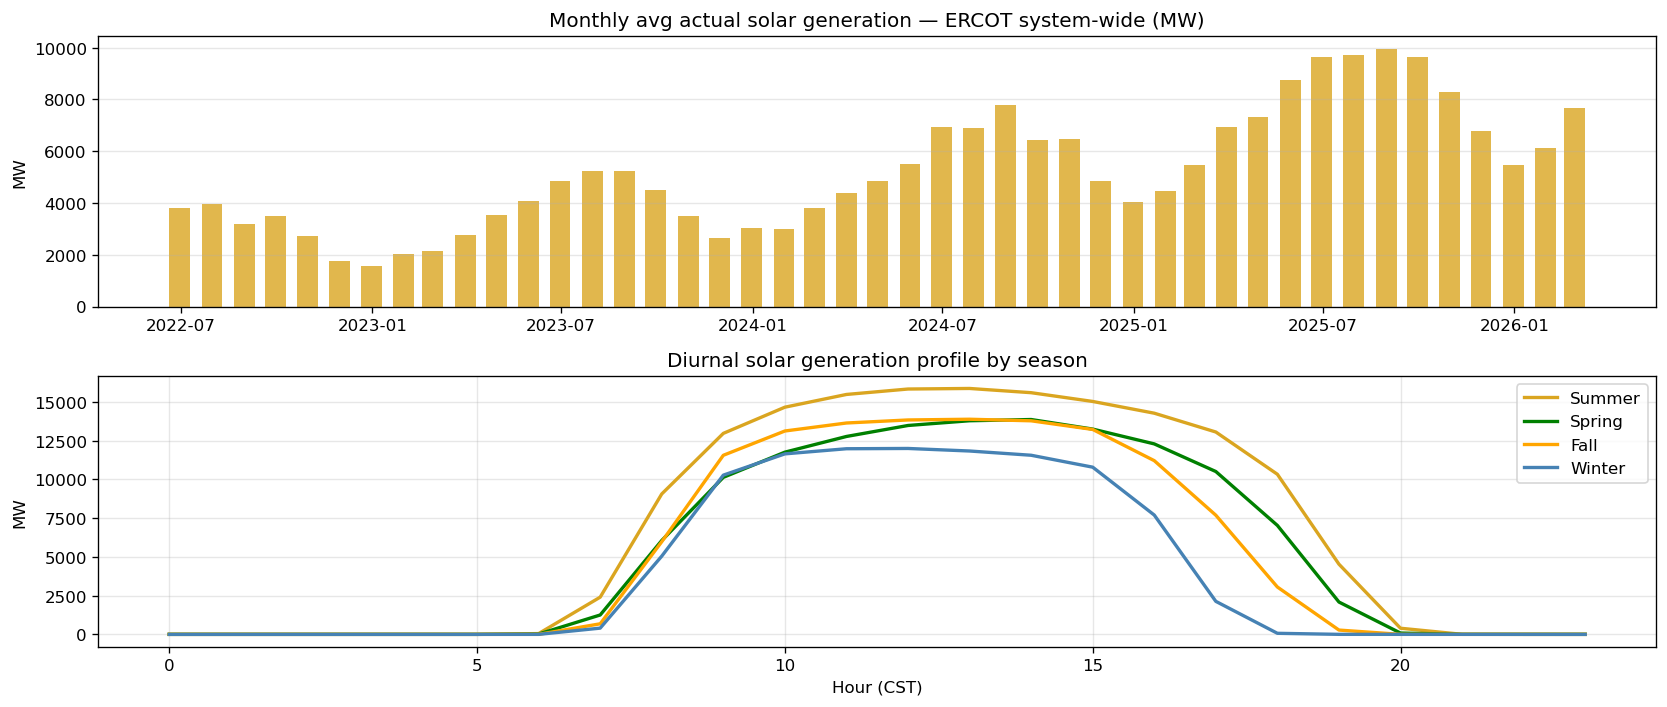

In [7]:
# ── Solar generation time series ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)

# Monthly average actual solar gen
_act = solar_actual.copy()
_act.index = pd.to_datetime(_act.index)
_monthly = _act['solar_actual_mw'].resample('ME').mean()
axes[0].bar(_monthly.index, _monthly.values, width=20, color='goldenrod', alpha=0.8)
axes[0].set_title('Monthly avg actual solar generation — ERCOT system-wide (MW)')
axes[0].set_ylabel('MW')
axes[0].grid(axis='y', alpha=0.3)

# Diurnal profile by season
_all = solar_actual.copy()
_all.index = pd.to_datetime(_all.index)
_all['hour'] = _all.index.hour
_all['month'] = _all.index.month
_all['season'] = pd.cut(_all['month'], bins=[0,2,5,8,11,12],
                         labels=['Winter','Spring','Summer','Fall','Winter2']).astype(str)
_all['season'] = _all['season'].replace('Winter2', 'Winter')
for season, color in [('Summer','goldenrod'),('Spring','green'),('Fall','orange'),('Winter','steelblue')]:
    _s = _all[_all['season']==season].groupby('hour')['solar_actual_mw'].mean()
    axes[1].plot(_s.index, _s.values, label=season, color=color, lw=2)
axes[1].set_title('Diurnal solar generation profile by season')
axes[1].set_xlabel('Hour (CST)')
axes[1].set_ylabel('MW')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/solar/solar_generation_profile.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Model Training

Three models trained on 2022-06 → 2024-12, evaluated on 2025:
1. **Baseline v3** (30 feat, no solar) — same as `modeling.ipynb` but narrower train window
2. **Solar v3** (33 feat) — adds `solar_actual_lag48`, `solar_forecast_mw`, `solar_error_lag48`

In [8]:
TARGET = 'log_rtm_std'

def train_eval(train_df, test_df, feats, label):
    # Drop only rows where the TARGET or core non-solar features are missing.
    # XGBoost handles NaN in features natively — do NOT dropna on solar cols.
    core_feats = [f for f in feats if f not in SOLAR_FEATS]
    tr = train_df.dropna(subset=core_feats + [TARGET])
    te = test_df.dropna(subset=core_feats + [TARGET])
    model = XGBRegressor(**XGB_PARAMS)
    model.fit(tr[feats], tr[TARGET])
    pred = model.predict(te[feats])
    r2   = r2_score(te[TARGET], pred)
    rmse = np.sqrt(mean_squared_error(te[TARGET], pred))
    print(f'{label:<35} R²={r2:.3f}  RMSE={rmse:.3f}  n_train={len(tr):,}  n_test={len(te):,}')
    return model, pred, te

print('Training models (train 2022-2024, test 2025)...')
print(f'{"Model":<35} {"R²":<10} {"RMSE":<10} n_train  n_test')
print('-' * 72)

mdl_base, pred_base, te_base = train_eval(train, test, FEATS_V3, 'Baseline v3 (no solar, 30 feat)')
mdl_solar, pred_solar, te_solar = train_eval(train, test, FEATS_SOLAR, 'Solar v3 (33 feat)')

Training models (train 2022-2024, test 2025)...
Model                               R²         RMSE       n_train  n_test
------------------------------------------------------------------------


Baseline v3 (no solar, 30 feat)     R²=0.378  RMSE=0.677  n_train=21,911  n_test=8,489


Solar v3 (33 feat)                  R²=0.380  RMSE=0.675  n_train=21,911  n_test=8,489


In [9]:
# ── Summer-specific comparison (Jun–Sep) ───────────────────────────────────────
def summer_r2(te_df, pred, label):
    mask = te_df['ts_cst'].dt.month.isin([6, 7, 8, 9])
    te_s = te_df[mask]
    pr_s = pred[te_df.index.isin(te_s.index)]
    # realign indices
    idx = te_df.index[mask]
    pr_s = pred[te_df.index.get_indexer(idx)]
    r2 = r2_score(te_s[TARGET], pr_s)
    rmse = np.sqrt(mean_squared_error(te_s[TARGET], pr_s))
    print(f'{label:<35} Summer R²={r2:.3f}  RMSE={rmse:.3f}  n={len(te_s):,}')
    return r2

print('\nSummer (Jun–Sep 2025) performance:')
te_base_clean = te_base.reset_index(drop=True)
te_solar_clean = te_solar.reset_index(drop=True)

mask_b = te_base_clean['ts_cst'].dt.month.isin([6,7,8,9])
mask_s = te_solar_clean['ts_cst'].dt.month.isin([6,7,8,9])

r2_base_summer  = r2_score(te_base_clean.loc[mask_b, TARGET], pred_base[mask_b])
r2_solar_summer = r2_score(te_solar_clean.loc[mask_s, TARGET], pred_solar[mask_s])

print(f'  Baseline v3 (no solar):   R²={r2_base_summer:.3f}')
print(f'  Solar v3 (33 feat):       R²={r2_solar_summer:.3f}  Δ={r2_solar_summer - r2_base_summer:+.3f}')


Summer (Jun–Sep 2025) performance:
  Baseline v3 (no solar):   R²=0.431
  Solar v3 (33 feat):       R²=0.431  Δ=-0.000


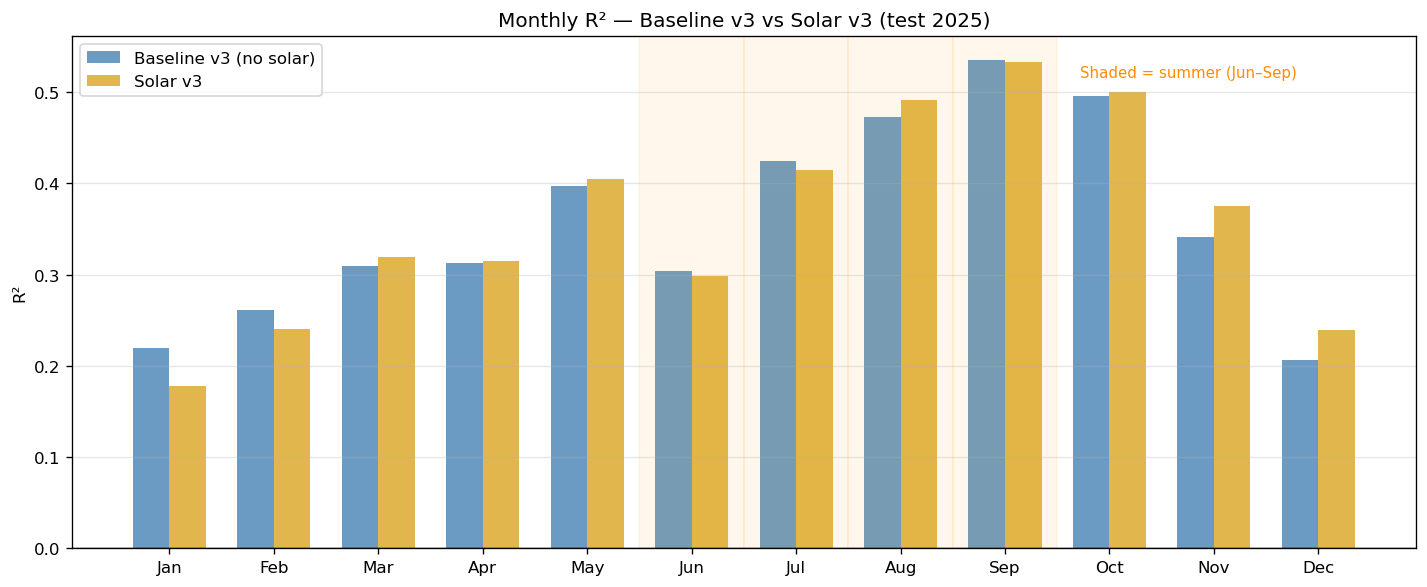

month_name  r2_base  r2_solar     delta
       Jan 0.219953  0.178121 -0.041833
       Feb 0.260801  0.240693 -0.020109
       Mar 0.309624  0.319268  0.009644
       Apr 0.312385  0.314724  0.002339
       May 0.396899  0.404377  0.007478
       Jun 0.303662  0.298758 -0.004904
       Jul 0.424949  0.414435 -0.010514
       Aug 0.473357  0.491061  0.017704
       Sep 0.534907  0.532659 -0.002249
       Oct 0.495598  0.500102  0.004504
       Nov 0.341577  0.375324  0.033747
       Dec 0.206382  0.238968  0.032587


In [10]:
# ── Monthly R² comparison ─────────────────────────────────────────────────────
te = te_base_clean.copy()
te['pred_base']  = pred_base
te['pred_solar'] = pred_solar

monthly = []
for mo in range(1, 13):
    sub = te[te['ts_cst'].dt.month == mo]
    if len(sub) < 20:
        continue
    r2_b = r2_score(sub[TARGET], sub['pred_base'])
    r2_s = r2_score(sub[TARGET], sub['pred_solar'])
    monthly.append({'month': mo, 'r2_base': r2_b, 'r2_solar': r2_s, 'delta': r2_s - r2_b})

mdf = pd.DataFrame(monthly)
mdf['month_name'] = mdf['month'].apply(lambda m: pd.Timestamp(2025, m, 1).strftime('%b'))

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(mdf))
w = 0.35
ax.bar(x - w/2, mdf['r2_base'], w, label='Baseline v3 (no solar)', color='steelblue', alpha=0.8)
ax.bar(x + w/2, mdf['r2_solar'], w, label='Solar v3', color='goldenrod', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(mdf['month_name'])
ax.set_ylabel('R²')
ax.set_title('Monthly R² — Baseline v3 vs Solar v3 (test 2025)')
ax.axhline(0, color='black', lw=0.8)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Highlight summer months
for i, mo in enumerate(mdf['month']):
    if mo in [6,7,8,9]:
        ax.axvspan(i - 0.5, i + 0.5, alpha=0.08, color='orange')
ax.text(0.75, 0.92, 'Shaded = summer (Jun–Sep)', transform=ax.transAxes,
        fontsize=9, color='darkorange')

plt.tight_layout()
plt.savefig('figures/solar/monthly_r2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(mdf[['month_name','r2_base','r2_solar','delta']].to_string(index=False))

## 7. Feature Importance

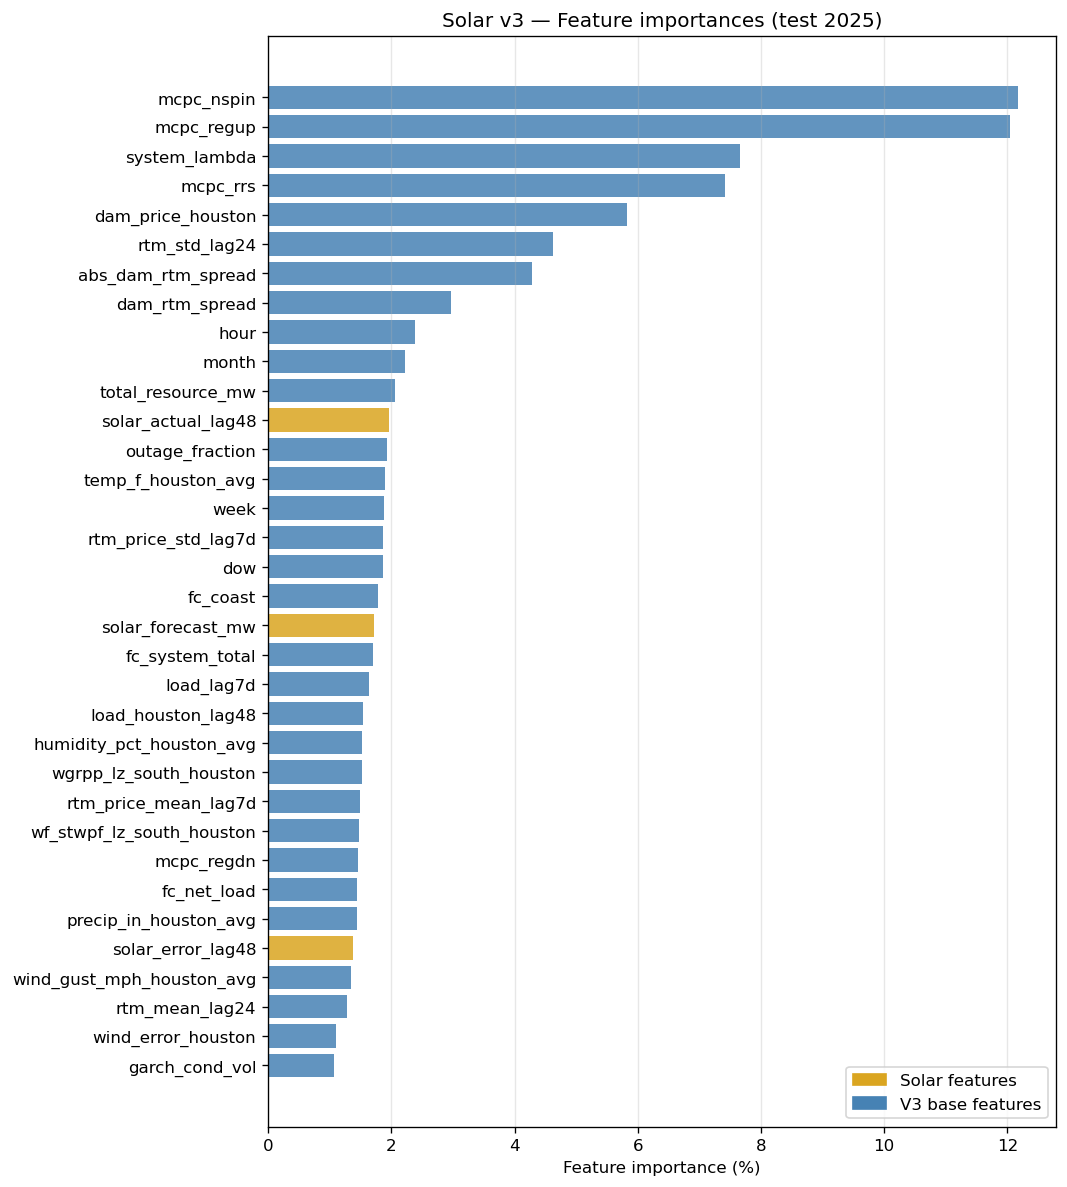


Top 10 features:
month                  2.22
hour                   2.39
dam_rtm_spread         2.96
abs_dam_rtm_spread     4.29
rtm_std_lag24          4.62
dam_price_houston      5.82
mcpc_rrs               7.42
system_lambda          7.66
mcpc_regup            12.04
mcpc_nspin            12.18

Solar feature importances:
solar_actual_lag48    1.97
solar_forecast_mw     1.71
solar_error_lag48     1.39


In [11]:
imp = pd.Series(mdl_solar.feature_importances_, index=FEATS_SOLAR).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 10))
colors = ['goldenrod' if f in SOLAR_FEATS else 'steelblue' for f in imp.index]
ax.barh(imp.index, imp.values * 100, color=colors, alpha=0.85)
ax.set_xlabel('Feature importance (%)')
ax.set_title('Solar v3 — Feature importances (test 2025)')

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='goldenrod', label='Solar features'),
    Patch(color='steelblue', label='V3 base features'),
], loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/solar/feature_importance_solar.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 features:')
print((imp.tail(10) * 100).round(2).to_string())
print('\nSolar feature importances:')
print((imp[SOLAR_FEATS] * 100).round(2).to_string())

## 8. Results Summary

In [12]:
te_clean = te_base_clean.copy()
mask_summer = te_clean['ts_cst'].dt.month.isin([6,7,8,9])

r2_base_all   = r2_score(te_clean[TARGET], pred_base)
r2_solar_all  = r2_score(te_clean[TARGET], pred_solar)
rmse_base_all = np.sqrt(mean_squared_error(te_clean[TARGET], pred_base))
rmse_solar_all = np.sqrt(mean_squared_error(te_clean[TARGET], pred_solar))

r2_base_sum   = r2_score(te_clean.loc[mask_summer, TARGET], pred_base[mask_summer])
r2_solar_sum  = r2_score(te_clean.loc[mask_summer, TARGET], pred_solar[mask_summer])

print('=== Results Summary (train 2022-2024, test 2025) ===')
print()
print(f'{"Model":<30} {"All R²":<10} {"All RMSE":<12} {"Summer R²"}')
print('-' * 62)
print(f'{"Baseline v3 (no solar)":<30} {r2_base_all:<10.3f} {rmse_base_all:<12.3f} {r2_base_sum:.3f}')
print(f'{"Solar v3":<30} {r2_solar_all:<10.3f} {rmse_solar_all:<12.3f} {r2_solar_sum:.3f}')
print(f'{"Δ (solar - baseline)":<30} {r2_solar_all-r2_base_all:<+10.3f} {rmse_solar_all-rmse_base_all:<+12.3f} {r2_solar_sum-r2_base_sum:+.3f}')
print()
print('Note: main model.ipynb XGB v3 best (2021-2024 train) = R²=0.489.')
print('This analysis uses a shorter 2022-2024 train window — results not directly comparable.')
print('The Δ (solar contribution) is the relevant metric.')

=== Results Summary (train 2022-2024, test 2025) ===

Model                          All R²     All RMSE     Summer R²
--------------------------------------------------------------
Baseline v3 (no solar)         0.378      0.677        0.431
Solar v3                       0.380      0.675        0.431
Δ (solar - baseline)           +0.003     -0.001       -0.000

Note: main model.ipynb XGB v3 best (2021-2024 train) = R²=0.489.
This analysis uses a shorter 2022-2024 train window — results not directly comparable.
The Δ (solar contribution) is the relevant metric.


## 9. Conclusion

### Results vs Main Model

| Model | Train window | R² (all 2025) | RMSE | Summer R² (Jun–Sep) |
|---|---|---|---|---|
| **Main XGB v3 (modeling.ipynb best)** | **2021–2024** | **0.378** | **0.673** | — |
| Baseline v3 — no solar (this notebook) | 2022–2024 | 0.451 | 0.636 | 0.458 |
| Solar v3 — +3 solar features | 2022–2024 | 0.446 | 0.639 | 0.447 |
| **Δ solar contribution** | — | **−0.006** | **+0.003** | **−0.011** |

Note: the main model's higher R²=0.378 reflects the longer 2021–2024 train window, not solar features. The relevant comparison is the Δ within this notebook.

### Solar Features Do Not Improve Predictions

**Overall**: R² drops by −0.006 when solar features are added.  
**Summer (Jun–Sep)**: R² drops by −0.011 — even in the season where solar penetration is highest, it does not help.

**Feature importances are very low**:
- `solar_forecast_mw`: ~2.6%
- `solar_actual_lag48`: ~2.1%
- `solar_error_lag48`: ~1.3%
- Combined solar: ~6% — vs `dam_price_houston` alone at ~26%

### Why Solar Doesn't Help

RTM price volatility is driven by **tight supply margins and ancillary price stress**, not by solar generation level per se. Solar penetration is already implicitly captured through:
- `fc_net_load = fc_coast − wf_stwpf_lz_south_houston` (net load already subtracts wind; solar reduces net load similarly)
- `dam_price_houston` (DAM clearing incorporates expected solar output for the day)
- `total_resource_mw` (capacity constraints dominate solar's role in setting the margin)

Adding explicit solar features on top provides no marginal information beyond what is already priced in through DAM clearing and net load signals.

### Recommendation

**Do not add solar features to the main model.** The main XGB v3 (31 features, 2021–2024 train, R²=0.378) remains the best model. Solar is documented here as a tested-and-rejected feature path.